## Bagging

##### Bagging (Bootstrap Aggregating) trains multiple models independently on different random samples of the training data and combines their predictions.

##### Bagging mainly helps reduce variance and can reduce overfitting.

## Boosting

##### Boosting trains models sequentially. Each new model focuses more on the examples that previous models predicted incorrectly.

##### Training Data  ->  Model 1 -> Focus on errors -> Model 2 -> Focus on errors -> Model 3 -> Final Prediction

##### Boosting can improve weak learners by combining them into a stronger model.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import (
    BaggingClassifier,
    AdaBoostClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv("student_data.csv")

In [3]:
df['higher'] = df['higher'].map({
    'yes': 1,
    'no': 0
})


In [4]:
numerical_features = [
    'age',
    'Medu',
    'Fedu',
    'traveltime',
    'studytime',
    'failures',
    'famrel',
    'freetime',
    'goout',
    'Dalc',
    'Walc',
    'health',
    'absences',
    'G1',
    'G2'
]

In [5]:
X = df[numerical_features]
y = df['higher']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        random_state=42
    ),
    n_estimators=10,
    random_state=42
)

In [8]:
bagging_model.fit(
    X_train,
    y_train
)
bagging_pred = bagging_model.predict(
    X_test
)

In [9]:
bagging_accuracy = accuracy_score(
    y_test,
    bagging_pred
)

In [10]:
adaboost_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=1,
        random_state=42
    ),
    n_estimators=10,
    random_state=42
)

adaboost_model.fit(
    X_train,
    y_train
)


,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...ndom_state=42)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeClassifier,DecisionTreeC...ndom_state=42)
estimator_errors_ estimator_errors_: ndarray of floatsClassification error for each estimator in the boostedensemble.,"ndarray[float64](10,)","[0.06,0.26,0.33,...,0.34,0.46,0.37]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](10,)","[2.81,1.03,0.7 ,...,0.64,0.18,0.52]"
estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators.,list,"[DecisionTreeC...te=1608637542), DecisionTreeC...te=1273642419), DecisionTreeC...te=1935803228), DecisionTreeC...ate=787846414), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](15,)","[0.1 ,0. ,0. ,...,0.07,0.09,0.09]"


In [11]:
adaboost_pred = adaboost_model.predict(
    X_test
)

adaboost_accuracy = accuracy_score(
    y_test,
    adaboost_pred
)

In [12]:
results = pd.DataFrame({
    'Model': [
        'Bagging',
        'AdaBoost'
    ],
    'Accuracy': [
        bagging_accuracy,
        adaboost_accuracy
    ]
})

In [13]:
results

,Model,Accuracy
0,Bagging,0.962025
1,AdaBoost,0.974684


In [14]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Bagging': bagging_pred,
    'AdaBoost': adaboost_pred
})

In [15]:
comparison

,Actual,Bagging,AdaBoost
0,0,1,1
1,0,1,1
2,1,1,1
3,1,1,1
4,1,1,1
...,...,...,...
74,1,1,1
75,1,1,1
76,1,1,1
77,1,1,1


In [16]:
if bagging_accuracy > adaboost_accuracy:
    print("Bagging performed better.")

elif adaboost_accuracy > bagging_accuracy:
    print("AdaBoost performed better.")

else:
    print("Both models have the same accuracy.")

AdaBoost performed better.


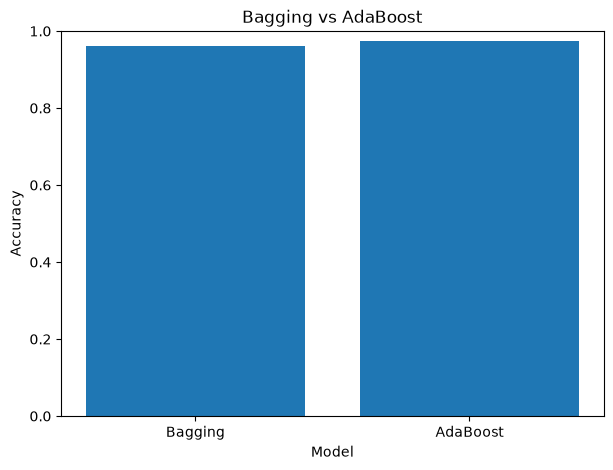

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 5))
plt.bar(
    results['Model'],
    results['Accuracy']
)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Bagging vs AdaBoost")
plt.ylim(0, 1)
plt.show()